Вычислить интеграл от осциллирующей функции с точностью $10^{-6}$:

$$ \int_0^1\frac{\sin{100x} \ \text{d}x}{1 + x} $$

# Метод Парабол(Симпосона)

$$ I_s = \frac{h}{3} \big[ f(x_0) + f(x_n) + \sum_{i = 1,3,...}^{n - 1}f(x_i) + 2\sum_{i = 2,4,...}^{n - 2}f(x_i) \big] $$

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def func(x):
    return np.sin(100 * x) / (1 + x)

In [10]:
x = np.linspace(0, 1, 1000)
y = [func(dx) for dx in x]

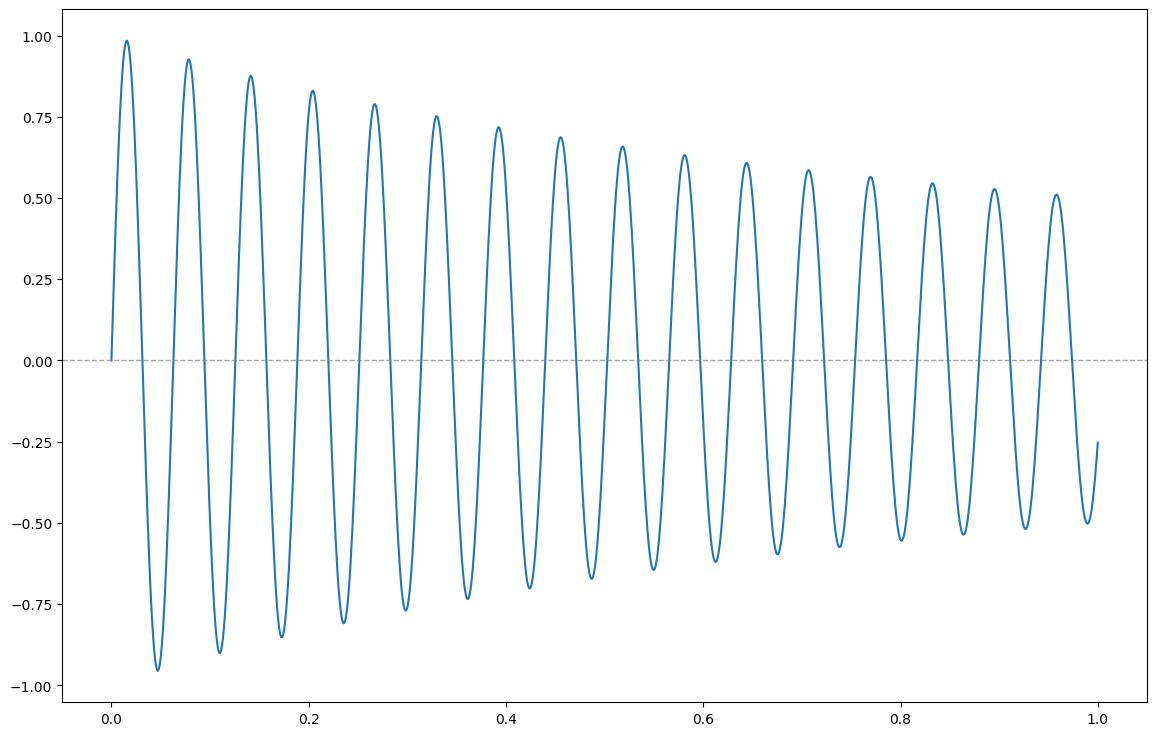

In [11]:
fig, ax = plt.subplots(figsize=(14, 9))  # Увеличили ширину

plt.plot(x, y)

ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.7)

In [16]:
def CalcIntegralSimpson(x_start, x_end, H):
    res = func(x_start) + func(x_end)
    
    N = int((x_end - x_start) // H) + 1
    
    # нечётные инедксы
    for i in range(1, N - 1, 2):
        res += func(x_start + i * H)
    # чётные индексы
    for i in range(3, N - 2, 2):
        res += 2 * func(x_start + i * H)
    
    res *= H / 3
    
    return res

In [21]:
def RungeRule(h):
    p = 1
    
    I_h = CalcIntegralSimpson(0, 1, h)
    I_h2 = CalcIntegralSimpson(0, 1, 2 * h)
    
    return np.abs(I_h2 - I_h) / (2**p - 1)

In [39]:
h = 0.1

Eps = 1e-6 # Погрешность 10^-6

while RungeRule(h) > Eps:
    RR = RungeRule(h)
    I = CalcIntegralSimpson(0, 1, h)
    print(f'Оценка по Рунге для h = {h}\ndelta = {RR}\nЗначение интеграла для h = {h}\nI = {I}\n')
    h /= 10

print(f'Итоговый шаг, для достижения погрешности E = {Eps}: h = {h}')
print(f'Значение интеграла для итогового шага: I = {I}')

Оценка по Рунге для h = 0.1
delta = 0.09403590717500471
Значение интеграла для h = 0.1
I = -0.07289602382861

Оценка по Рунге для h = 0.01
delta = 0.003551681632620966
Значение интеграла для h = 0.01
I = 0.002006832754544307

Оценка по Рунге для h = 0.001
delta = 0.00010515016418193631
Значение интеграла для h = 0.001
I = 0.0029986019175530553

Оценка по Рунге для h = 0.0001
delta = 1.630984739018227e-05
Значение интеграла для h = 0.0001
I = 0.002866331132862249

Оценка по Рунге для h = 1e-05
delta = 1.6822689308622005e-06
Значение интеграла для h = 1e-05
I = 0.0028513264096584287

Итоговый шаг, для достижения погрешности E = 1e-06: h = 1.0000000000000002e-06
Значение интеграла для итогового шага: I = 0.0028513264096584287
